# 02. Pipeline de Pré-processamento e Escalonamento

Este notebook detalha o tratamento de dados ausentes, a divisão temporal para evitar vazamento de dados (*data leakage*) e a normalização com o RobustScaler.

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import RobustScaler

# Adicionar diretório raiz ao path para importar modulos do src
sys.path.append(os.path.abspath('..'))

## 1. Tratamento de Valores Ausentes

In [ ]:
from src.data.preprocess import handle_missing

# Exemplo de simulação de falha de sensor (NaN)
df_test_nan = pd.DataFrame({
    'sensor_val': [1.0, 1.2, np.nan, np.nan, 1.5, np.nan, np.nan, np.nan, np.nan, 2.0]
})

df_fixed = handle_missing(df_test_nan, max_interp_hours=2, max_ffill_hours=2)
print("Antes do tratamento:")
print(df_test_nan.values.flatten())
print("Depois do tratamento:")
print(df_fixed.values.flatten())

Antes do tratamento:
[1.  1.2 nan nan 1.5 nan nan nan nan 2. ]
Depois do tratamento:
[1.  1.2 1.3 1.4 1.5 1.6 1.7 1.7 1.7 2. ]


c:\Users\vinic\OneDrive\Desktop\LSTMVAE\lstm_autoencoder_rs\src\data\preprocess.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill', limit=max_ffill_hours)


## 2. Escalonador Robusto contra Outliers (RobustScaler)

In [ ]:
# Carregando os dados brutos e executando o script principal de pre-processamento
from src.data.preprocess import run_preprocessing

run_preprocessing()

FileNotFoundError: Os arquivos brutos inmet.csv e ana.csv precisam ser gerados primeiro.

## 3. Analisando as Bases Escaladas

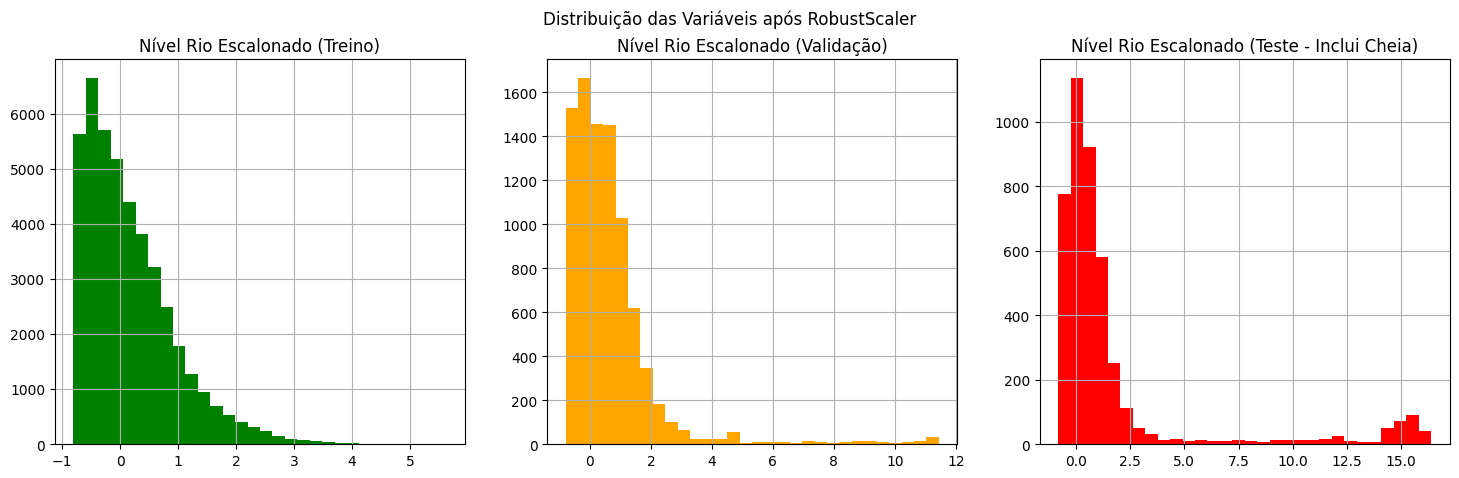

In [ ]:
df_train_scaled = pd.read_csv('../data/processed/train.csv')
df_val_scaled = pd.read_csv('../data/processed/val_labeled.csv')
df_test_scaled = pd.read_csv('../data/processed/test_labeled.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_train_scaled['nivel_rio'].hist(ax=axes[0], bins=30, color='g')
axes[0].set_title('Nível Rio Escalonado (Treino)')

df_val_scaled['nivel_rio'].hist(ax=axes[1], bins=30, color='orange')
axes[1].set_title('Nível Rio Escalonado (Validação)')

df_test_scaled['nivel_rio'].hist(ax=axes[2], bins=30, color='r')
axes[2].set_title('Nível Rio Escalonado (Teste - Inclui Cheia)')

plt.suptitle('Distribuição das Variáveis após RobustScaler')
plt.show()

## 4. Criando Sequências Deslizantes (Sliding Windows)

In [ ]:
from src.data.preprocess import create_sequences
features = ['precipitacao', 'nivel_rio', 'velocidade_vento', 'temperatura', 'umidade', 'pressao', 'vazao']

X_train = create_sequences(df_train_scaled, features, window=72)
print("Shape do Input do Autoencoder:", X_train.shape)
print("Formato: (N_janelas, Timesteps, N_features)")

Shape do Input do Autoencoder: (43753, 72, 7)
Formato: (N_janelas, Timesteps, N_features)
